In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [35]:
df = pd.read_csv("EFIplus_medit.csv", sep=";")

In [36]:
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [37]:
df.columns

Index(['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name',
       'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect',
       'Calib_hydrol',
       ...
       'Squalius malacitanus', 'Squalius pyrenaicus', 'Squalius torgalensis',
       'Thymallus thymallus', 'Tinca tinca', 'Zingel asper', 'Squalius sp',
       'Barbatula sp', 'Phoxinus sp', 'Iberochondrostoma_sp'],
      dtype='object', length=164)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5011 entries, 0 to 5010
Columns: 164 entries, Site_code to Iberochondrostoma_sp
dtypes: float64(38), int64(120), object(6)
memory usage: 6.3+ MB


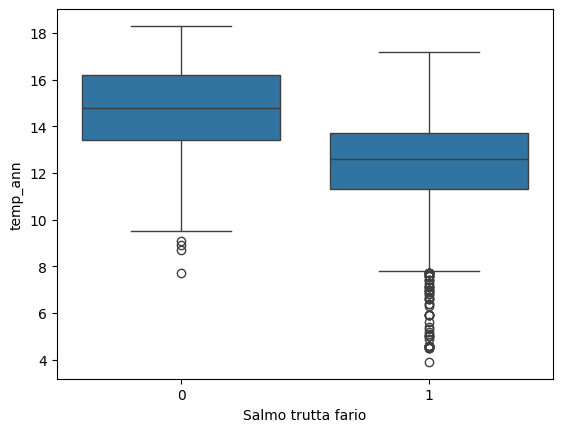

In [39]:
sns.boxplot(x="Salmo trutta fario", y="temp_ann", data=df)
plt.show()

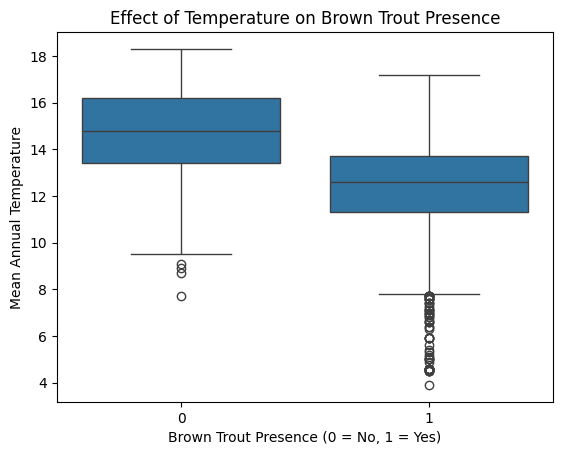

In [40]:
sns.boxplot(x="Salmo trutta fario", y="temp_ann", data=df)
plt.title("Effect of Temperature on Brown Trout Presence")
plt.xlabel("Brown Trout Presence (0 = No, 1 = Yes)")
plt.ylabel("Mean Annual Temperature")
plt.show()

The boxplot shows that sites where Salmo trutta fario is present (value = 1) tend to have lower mean annual temperatures compared to sites where it is absent (value = 0).

This suggests that brown trout prefer colder environments, and higher temperatures may negatively affect their presence.

Therefore, temperature appears to be an important environmental factor influencing the distribution of this species.

In [41]:
df["Catchment_name"].unique()

array(['Guadalquivir', 'Tejo', 'Douro', 'Segura', 'Jucar', 'Ebro',
       'Cantabrica', 'Guadia', 'Jucar-Ebro', 'Sur', 'Galiza-Norte',
       'Minho', 'Galiza-Sul', 'Catala', 'Segura-Jucar', 'Garonne',
       'Rhone', 'South_France_E', 'South_France_W', 'Corse',
       'Ombrone-Tevere', 'Campania-South', 'Tevere', 'Arno-Ombrone',
       'Italia-Veneto', 'Sardinia', 'Ombrone', 'Saline-Pescara-Sangro',
       'Oeste', 'Mira', 'Mondego', 'Odelouca', 'Algarve-Sotavento',
       'Algarve-barlavento', 'Sado', 'Tejo-Sado', 'Vouga',
       'EntreDouroeVouga', 'Vouga-Mondego'], dtype=object)

In [42]:
df_subset = df[df["Catchment_name"].isin(["Minho", "Tejo"])]

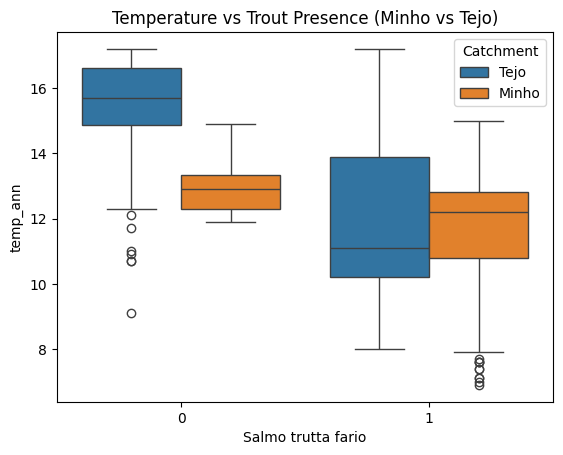

In [43]:
sns.boxplot(x="Salmo trutta fario", y="temp_ann", hue="Catchment_name", data=df_subset)
plt.title("Temperature vs Trout Presence (Minho vs Tejo)")
plt.legend(title="Catchment", loc="upper right")  # 👈 ADD HERE
plt.show()

The relationship between temperature and brown trout presence differs between catchments.

In the Tejo catchment, there is a clear difference: sites where trout are present have significantly lower temperatures compared to sites where they are absent. This indicates a strong negative effect of temperature on trout presence.

In contrast, the Minho catchment shows a smaller difference in temperature between presence and absence, suggesting a weaker effect.

Overall, temperature appears to have a stronger influence on trout presence in Tejo than in Minho.

In [44]:
import numpy as np

def cohens_d(group1, group2):
    return (np.mean(group1) - np.mean(group2)) / np.sqrt((np.std(group1)**2 + np.std(group2)**2)/2)

In [45]:
d_minho = cohens_d(
    minho[minho["Salmo trutta fario"] == 1]["temp_ann"],
    minho[minho["Salmo trutta fario"] == 0]["temp_ann"]
)

print("Cohen's d (Minho):", d_minho)

Cohen's d (Minho): -0.875610496532697


In [46]:
d_tagus = cohens_d(
    tagus[tagus["Salmo trutta fario"] == 1]["temp_ann"],
    tagus[tagus["Salmo trutta fario"] == 0]["temp_ann"]
)

print("Cohen's d (Tejo):", d_tagus)

Cohen's d (Tejo): -2.0545117549594156


The effect size (Cohen’s d) was calculated to quantify the difference in temperature between sites with and without brown trout.

The results show a large negative effect size in both catchments (Minho: d = -0.88; Tejo: d = -2.05), indicating that sites where brown trout are present tend to have lower temperatures.

The effect is considerably stronger in the Tejo catchment, where the magnitude of the effect size is very large, suggesting that temperature has a stronger influence on trout presence in Tejo compared to Minho.

These results confirm the patterns observed in the visualization.

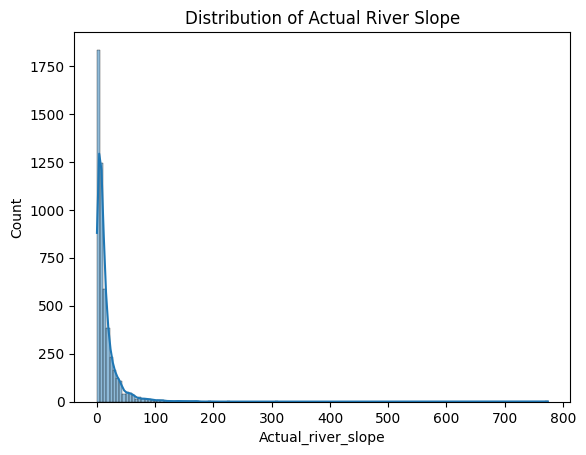

In [47]:
sns.histplot(df["Actual_river_slope"], kde=True)
plt.title("Distribution of Actual River Slope")
plt.show()

In [48]:
slope = df["Actual_river_slope"].dropna()

In [50]:
stat, p_value = stats.shapiro(slope)
print("Statistic:", stat)
print("p-value:", p_value)

Statistic: 0.5163239471574013
p-value: 2.591069478544196e-79


The normality of the variable actual_river_slope was assessed using both visualization and the Shapiro-Wilk test.

Missing values were removed prior to the analysis.

The histogram suggests that the distribution is not symmetric and deviates from a normal distribution.

The Shapiro-Wilk test returned a statistic of 0.516 and a p-value of 2.59 × 10⁻⁷⁹, which is far below the significance level of 0.05.

Therefore, we reject the null hypothesis and conclude that the data is not normally distributed.

The extremely small p-value indicates strong evidence against normality, confirming the visual assessment.

In [51]:
means = []

In [52]:
for i in range(100):
    sample = slope.sample(2000, replace=True)
    means.append(sample.mean())

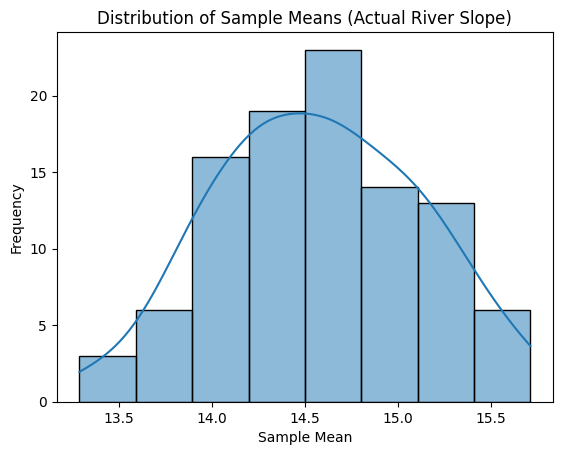

In [53]:
sns.histplot(means, kde=True)
plt.title("Distribution of Sample Means (Actual River Slope)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

In [54]:
stat_means, p_means = stats.shapiro(means)
print("Statistic:", stat_means)
print("p-value:", p_means)

Statistic: 0.9883014359686756
p-value: 0.5306923371126445


To investigate the distribution of sample means, 100 samples of size 2000 were drawn with replacement from the variable actual_river_slope, and the mean of each sample was computed.

The histogram of the sample means shows a symmetric, bell-shaped distribution, suggesting approximate normality.

The Shapiro-Wilk test returned a statistic of 0.988 and a p-value of 0.531, which is greater than the significance level of 0.05.

Therefore, we fail to reject the null hypothesis and conclude that the distribution of sample means does not significantly deviate from normality.

This result is consistent with the Central Limit Theorem, which states that the distribution of sample means tends toward normality regardless of the original data distribution.